# Replication: "The Benefits of College Athletic Success" (Anderson, 2017)

This notebook runs the full replication pipeline (equivalent to running
`01_data_cleaning.py`, `02_analysis.py`, and `03_tables_figures.py` from the
command line, in that order) and displays the final results inline.

See `README.md` (repository root) for the full write-up, and
`report/replication_report.pdf` for the complete replication report.

**Run order matters**: run all cells top to bottom. Each stage depends on the
previous stage's output.

## Stage 1: Data cleaning and variable construction

In [1]:
import subprocess, sys
result = subprocess.run([sys.executable, "01_data_cleaning.py"], capture_output=True, text=True, cwd="../code")
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("01_data_cleaning.py failed")

Step 1/6: loading and cleaning game-level football data...
Step 2/6: fitting propensity scores...
  raw-line pscore model: N=28076, range=[0.0046, 0.9936] (paper reports [0.005, 0.994])
Step 3/6: aggregating to the team-season level...
Step 4/6: merging with institutional (donations/admissions) data...
  merged panel: 2492 team-year observations
Step 5/6: constructing lags/leads, reporting-date fixes, derived variables...
Step 6/6: constructing inverse-probability-of-treatment weights...

Done. Saved ../data/processed/analytic_panel.pkl  (shape: (2492, 524))



## Stage 2: Estimation (STE and IV models, all samples)

In [2]:
result = subprocess.run([sys.executable, "02_analysis.py"], capture_output=True, text=True, cwd="../code")
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("02_analysis.py failed")

Loading analytic panel...
Table 1: summary statistics...
table3_all: running STE and IV models...
table4_bcs: running STE and IV models...
table5_nonbcs: running STE and IV models...
table6 (weeks 5+ robustness check): running STE and IV models...

Done. Raw replicated tables written to ../output/tables/



## Stage 3: Comparison to published results, tables, and figures

In [3]:
result = subprocess.run([sys.executable, "03_tables_figures.py"], capture_output=True, text=True, cwd="../code")
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("03_tables_figures.py failed")

REPLICATION ACCURACY SUMMARY (across all 40 outcome x table estimates)
STE model : correlation = 1.000 | sign agreement = 40/40 | N exact match = 33/40
IV model  : correlation = 0.998 | sign agreement = 38/40 | N exact match = 35/40

THREE-WIN SCENARIO (paper's own choice of estimator per outcome:
IV for donations/applications/acceptance/enrollment, STE for SAT)
  Alumni athletic donations ($): 393,027.1  (16.1% of base 2,438,512.4)
  Applications (#): 403.1  (2.9% of base 13,748.4)
  Acceptance rate (pct pts): -0.9  (-1.3% of base 69.8)
  In-state enrollment (#): 44.6  (1.8% of base 2,540.8)
  25th pctile SAT (pts): 2.5  (0.2% of base 1,054.1)

Building figures...
Done. Figures written to ../output/figures/, comparison table written to ../output/tables/comparison_all.csv



## Inline view: Table 3 (All FBS), replicated vs. published

In [4]:
import sys
sys.path.insert(0, "../code")
import pandas as pd
from published_numbers import TABLE3_ORIG

t3 = pd.read_csv("../output/tables/table3_all.csv")
rows = []
for _, r in t3.iterrows():
    o = TABLE3_ORIG[r["outcome"]]
    divisor = 1000 if r["outcome"] in {"alumni_ops_athletics", "alum_non_athl_ops", "alumni_total_giving"} else 1
    scale = 100 if r["outcome"] == "acceptance_rate" else 1
    rows.append({
        "Outcome": r["label"],
        "Original (STE)": o["ste"], "Replicated (STE)": round(r["coef_ste"] / divisor / scale, 4),
        "Original (IV)": o["iv"], "Replicated (IV)": round(r["coef_iv"] / divisor / scale, 4),
    })
pd.DataFrame(rows).set_index("Outcome")

,Original (STE),Replicated (STE),Original (IV),Replicated (IV)
Outcome,,,,
Alumni Athletic Operating Donations,191.2000,191.2433,136.4000,131.0090
Alumni Nonathletic Operating Donations,-137.4000,-137.4120,227.9000,227.1782
Total Alumni Donations,267.4000,267.3785,311.9000,278.7675
Alumni Giving Rate,0.0002,0.0002,-0.0001,-0.0002
Academic Reputation,0.0030,0.0034,0.0040,0.0036
Applicants,81.1000,81.1025,135.3000,134.3734
Acceptance Rate,-0.0030,-0.0033,-0.0030,-0.0030
First-Time Out-of-State Enrollment,1.6000,1.6003,-0.4000,-0.5393
First-Time In-State Enrollment,12.6000,12.5702,15.2000,14.8551


## Inline view: replication-accuracy comparison across all 40 estimates

In [5]:
cmp = pd.read_csv("../output/tables/comparison_all.csv")
corr_ste = cmp[["orig_ste", "my_ste"]].corr().iloc[0, 1]
corr_iv = cmp[["orig_iv", "my_iv"]].corr().iloc[0, 1]
print(f"STE model correlation with published coefficients: {corr_ste:.3f}")
print(f"IV model correlation with published coefficients:  {corr_iv:.3f}")
print(f"STE sign agreement: {cmp['ste_same_sign'].sum()}/{len(cmp)}")
print(f"IV sign agreement:  {cmp['iv_same_sign'].sum()}/{len(cmp)}")

STE model correlation with published coefficients: 1.000
IV model correlation with published coefficients:  0.998
STE sign agreement: 40/40
IV sign agreement:  38/40


## Figures

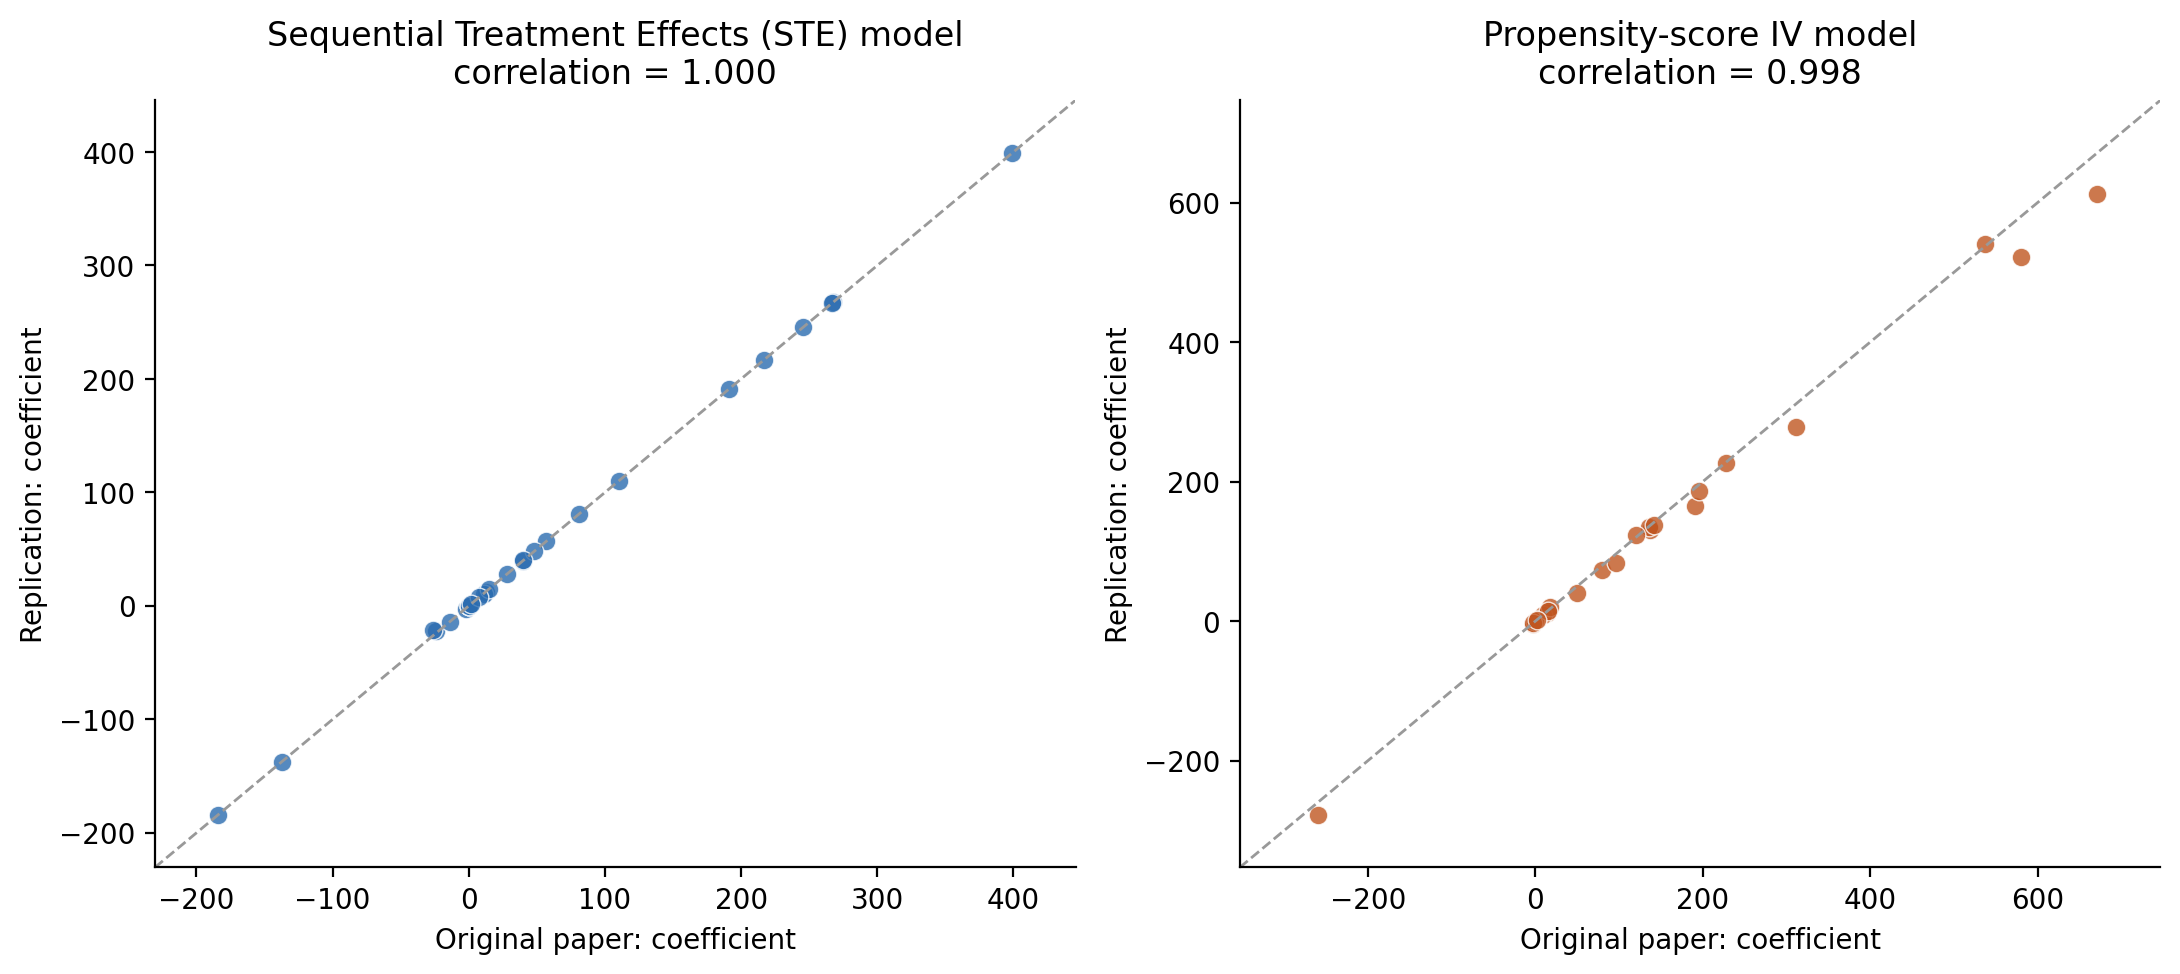

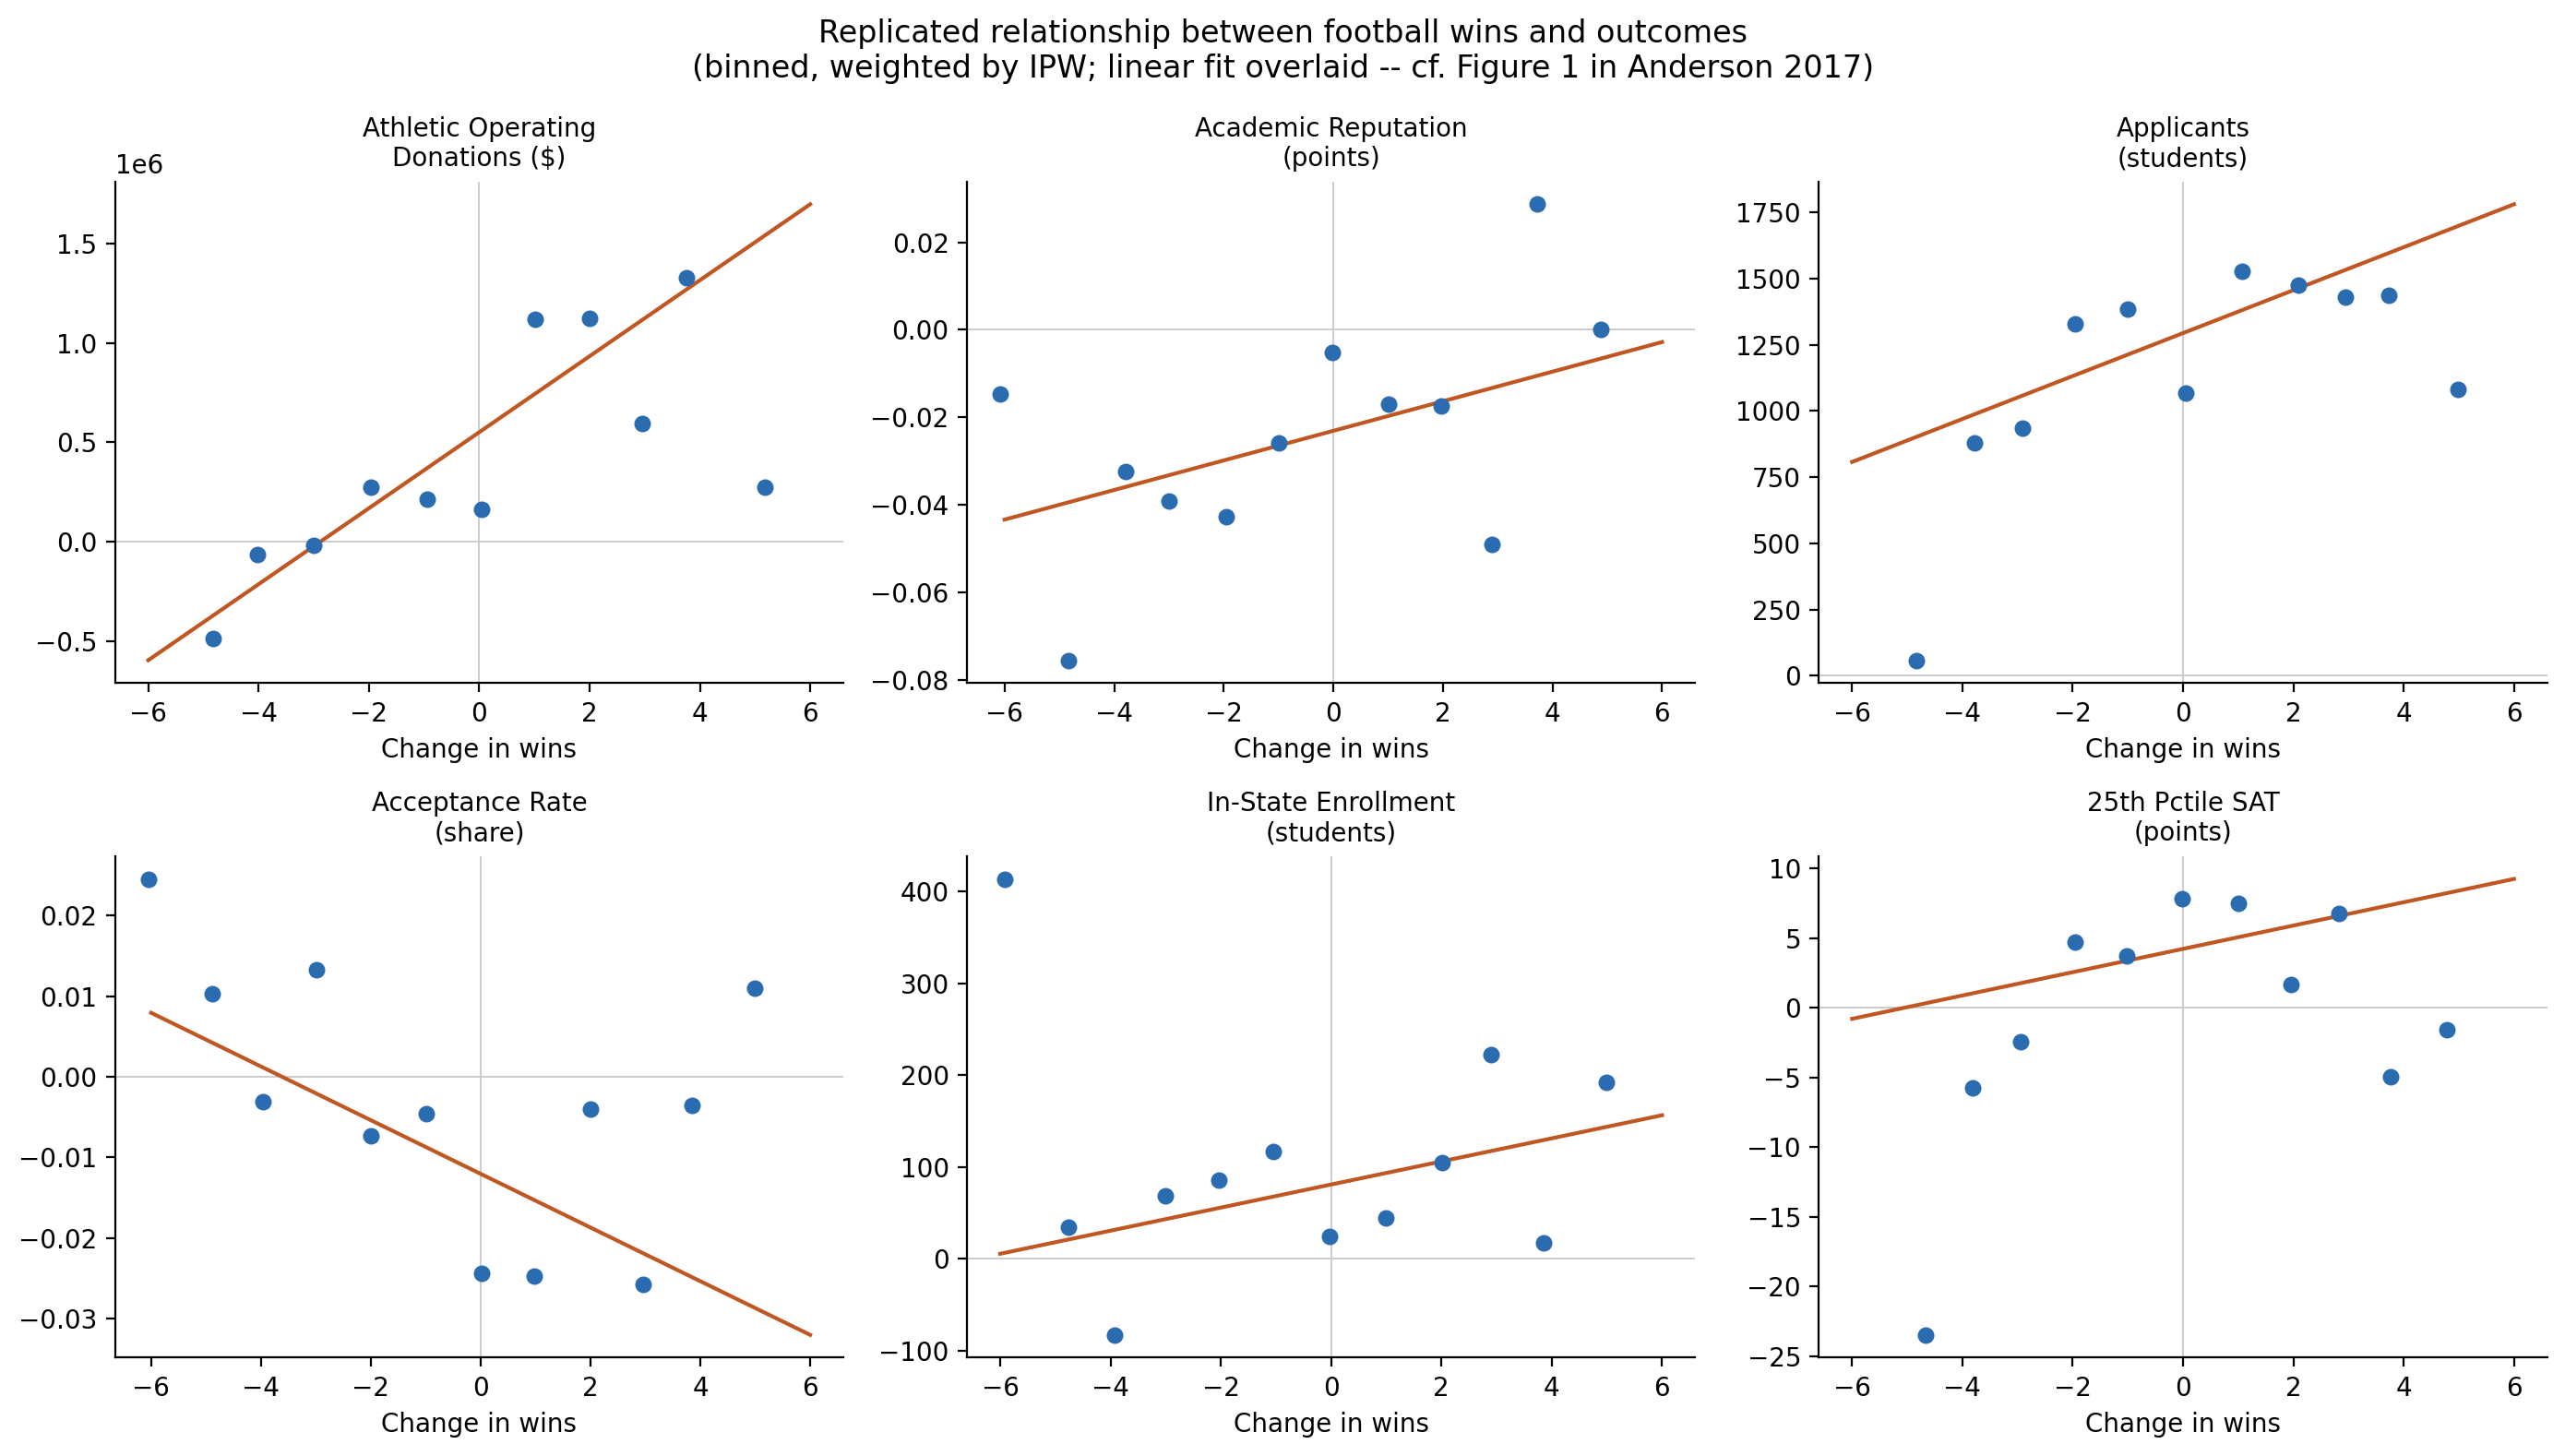

In [6]:
from IPython.display import Image, display
display(Image("../output/figures/fig_parity.png"))
display(Image("../output/figures/fig_binscatter.png"))